# Phase 3 — Stratégie de split alignée business

**Objectifs**
1. Comparer un split naïf stratifié vs un split simulant la non-réponse.
2. Quantifier l'écart de distribution entre répondants et silencieux.
3. Sauvegarder les deux splits — celui qu'on utilisera pour entraîner ET un baseline méthodologique.
4. Produire les figures pour le rapport final.

**Pourquoi cette phase est critique**
Un split aléatoire stratifié donne des chiffres
flatteurs mais trompeurs : il évalue sur des répondants alors qu'on déploie sur des silencieux.

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATA_PROCESSED, FIGURES_DIR, NPS_CLASSES, DEFAULT_TARGET
from src.data.split import (
    compute_response_propensity,
    make_naive_splits,
    make_response_biased_splits,
    summarize_split,
    save_splits,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")

Setup OK


## 1. Chargement du dataset modélisable

In [3]:
df = pd.read_parquet(DATA_PROCESSED / "dataset.parquet")
print(f"Shape: {df.shape}")
print(f"Index: {df.index.name}")
print(f"Targets: {[c for c in df.columns if c.startswith('NPS_')]}")
print(f"Default target: {DEFAULT_TARGET}")
df.head(3)

Shape: (7043, 42)
Index: Customer ID
Targets: ['NPS_baseline', 'NPS_alternative']
Default target: NPS_baseline


,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Age,Under 30,Married,Number of Dependents,Population,NPS_baseline,NPS_alternative
Customer ID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,0,20.94,129.09,37,No,No,0,58198,Detractor,Detractor
9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,0,18.24,169.89,19,Yes,No,2,43019,Detractor,Detractor
9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,0,97.20,917.70,31,No,No,2,62784,Detractor,Passive


## 2. Stratégie A — Split naïf stratifié (baseline méthodologique)

C'est le split par défaut qu'on aurait fait sans réfléchir. Il sert de **référence** : on mesurera l'écart de performance entre ce split et le split response-biased pour quantifier l'effet de la sélection.

In [4]:
splits_naive = make_naive_splits(df, target_col=DEFAULT_TARGET)
print("Distribution per split:\n")
print(summarize_split(splits_naive, df, target_col=DEFAULT_TARGET).to_string(index=False))

Distribution per split:

split    n  pct  %_Detractor  %_Passive  %_Promoter  mean_tenure  mean_age
train 4225 60.0         58.3       25.4        16.3         32.6      46.6
  val 1409 20.0         58.3       25.4        16.3         31.8      46.5
 test 1409 20.0         58.3       25.4        16.3         32.2      46.2


## 3. Stratégie B — Split simulant la non-réponse

**Mécanisme** : on attribue à chaque client une probabilité de répondre au survey, fonction de signaux d'engagement (tenure dominant, paperless billing, autopay, contrat). On échantillonne 15 % des clients selon ces probabilités, ce sont les **respondents simulés**. Les 85 % restants sont les **silencieux** sur lesquels on veut prédire en production.

**Hypothèse défendable** : les clients engagés répondent davantage aux surveys (corroboré par la littérature CX télécom).

In [5]:
propensity = compute_response_propensity(df, seed=42)
print(f"Propensity distribution:")
print(propensity.describe().round(3))

Propensity distribution:
count    7043.000
mean        0.548
std         0.324
min         0.020
25%         0.226
50%         0.558
75%         0.883
max         0.995
Name: response_propensity, dtype: float64


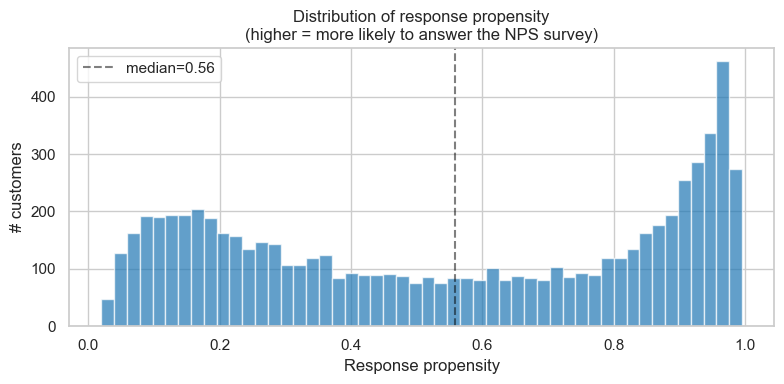

In [6]:
# Visualize the propensity distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(propensity, bins=50, color="#1f77b4", edgecolor="white", alpha=0.7)
ax.set_xlabel("Response propensity")
ax.set_ylabel("# customers")
ax.set_title("Distribution of response propensity\n"
             "(higher = more likely to answer the NPS survey)")
ax.axvline(propensity.median(), ls="--", color="black", alpha=0.5,
           label=f"median={propensity.median():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "16_response_propensity.png")
plt.show()

In [7]:
# Generate the response-biased splits
splits_rb, propensity = make_response_biased_splits(df, target_col=DEFAULT_TARGET)
print("Distribution per split:\n")
print(summarize_split(splits_rb, df, target_col=DEFAULT_TARGET).to_string(index=False))

Distribution per split:

          split    n  pct  %_Detractor  %_Passive  %_Promoter  mean_tenure  mean_age
    silent_test 5987 85.0         59.0       24.8        16.2         30.4      46.3
            val  211  3.0         54.0       28.9        17.1         41.6      47.4
respondent_test  211  3.0         54.0       28.9        17.1         42.8      47.9
          train  634  9.0         54.1       28.9        17.0         44.5      47.8


## 4. Quantifier le shift respondents vs silent

C'est le cœur de la défense méthodologique. On montre que le pool respondents est **systématiquement différent** du pool silent — c'est exactement la covariate shift que le brief évoque.

In [8]:
# Build a flag: is this customer a "respondent" in the biased setup?
is_respondent = splits_rb.isin(["train", "val", "respondent_test"])

# Compare distributions on key features
shift_metrics = []
features_to_compare = [
    ("Tenure Months", "numeric"),
    ("Age", "numeric"),
    ("Monthly Charges", "numeric"),
    ("Number of Referrals", "numeric"),
    ("Paperless Billing", "categorical"),
    ("Contract", "categorical"),
]

for feat, kind in features_to_compare:
    if feat not in df.columns:
        continue
    if kind == "numeric":
        m_resp = df.loc[is_respondent, feat].mean()
        m_silent = df.loc[~is_respondent, feat].mean()
        shift_metrics.append({
            "feature": feat,
            "type": kind,
            "respondents": round(m_resp, 2),
            "silent": round(m_silent, 2),
            "shift": round(m_resp - m_silent, 2),
            "shift_pct": f"{(m_resp / m_silent - 1) * 100:+.1f}%" if m_silent else "n/a",
        })
    else:
        # For categorical, compare the dominant category share
        top_cat = df[feat].value_counts().index[0]
        s_resp = (df.loc[is_respondent, feat] == top_cat).mean()
        s_silent = (df.loc[~is_respondent, feat] == top_cat).mean()
        shift_metrics.append({
            "feature": f"{feat}={top_cat}",
            "type": kind,
            "respondents": f"{s_resp * 100:.1f}%",
            "silent": f"{s_silent * 100:.1f}%",
            "shift": round((s_resp - s_silent) * 100, 1),
            "shift_pct": f"{(s_resp / s_silent - 1) * 100:+.1f}%" if s_silent else "n/a",
        })

shift_df = pd.DataFrame(shift_metrics)
print("Distribution shift respondents vs silent:\n")
print(shift_df.to_string(index=False))

Distribution shift respondents vs silent:

                feature        type respondents silent  shift shift_pct
          Tenure Months     numeric       43.58  30.39  13.18    +43.4%
                    Age     numeric       47.74  46.29   1.44     +3.1%
        Monthly Charges     numeric       68.45  64.11   4.34     +6.8%
    Number of Referrals     numeric        2.44   1.87   0.57    +30.5%
  Paperless Billing=Yes categorical       63.5%  58.5%   5.10     +8.7%
Contract=Month-to-month categorical       39.8%  57.7% -17.90    -31.1%


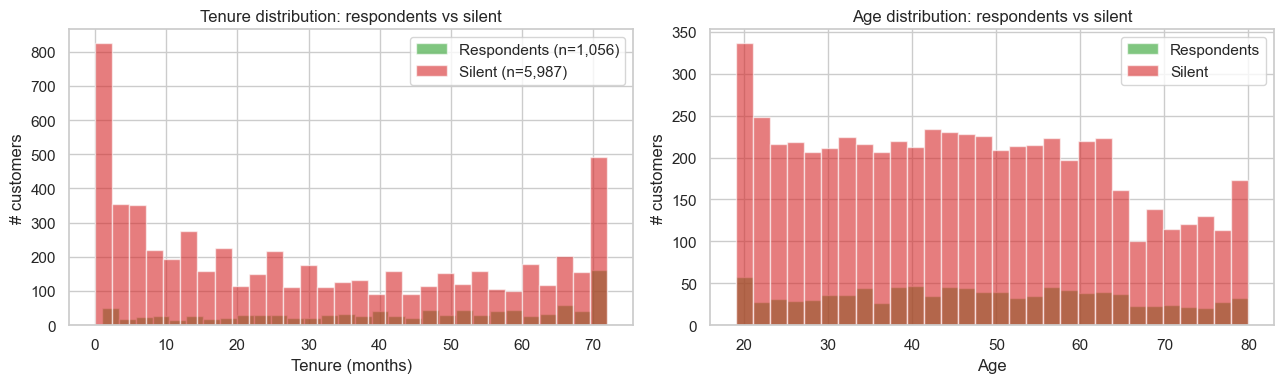

In [9]:
# Plot: tenure distribution respondents vs silent
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tenure
if "Tenure Months" in df.columns:
    axes[0].hist(df.loc[is_respondent, "Tenure Months"], bins=30, alpha=0.6,
                 label=f"Respondents (n={is_respondent.sum():,})", color="#2ca02c")
    axes[0].hist(df.loc[~is_respondent, "Tenure Months"], bins=30, alpha=0.6,
                 label=f"Silent (n={(~is_respondent).sum():,})", color="#d62728")
    axes[0].set_xlabel("Tenure (months)")
    axes[0].set_ylabel("# customers")
    axes[0].set_title("Tenure distribution: respondents vs silent")
    axes[0].legend()

# Age
if "Age" in df.columns:
    axes[1].hist(df.loc[is_respondent, "Age"], bins=30, alpha=0.6,
                 label=f"Respondents", color="#2ca02c")
    axes[1].hist(df.loc[~is_respondent, "Age"], bins=30, alpha=0.6,
                 label=f"Silent", color="#d62728")
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("# customers")
    axes[1].set_title("Age distribution: respondents vs silent")
    axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "17_shift_distributions.png")
plt.show()

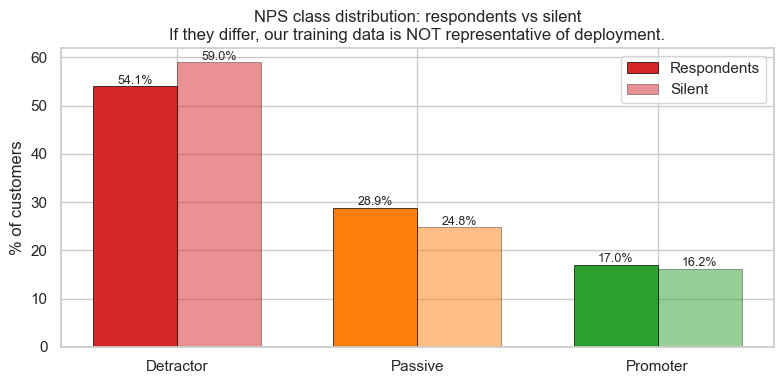

In [10]:
# Plot: NPS distribution within respondents vs silent
fig, ax = plt.subplots(figsize=(8, 4))

dist_resp = df.loc[is_respondent, DEFAULT_TARGET].value_counts(normalize=True).reindex(NPS_CLASSES) * 100
dist_silent = df.loc[~is_respondent, DEFAULT_TARGET].value_counts(normalize=True).reindex(NPS_CLASSES) * 100

x = np.arange(len(NPS_CLASSES))
width = 0.35
ax.bar(x - width / 2, dist_resp.values, width, label="Respondents",
       color=[NPS_PALETTE[c] for c in NPS_CLASSES], edgecolor="black", linewidth=0.5)
ax.bar(x + width / 2, dist_silent.values, width, label="Silent",
       color=[NPS_PALETTE[c] for c in NPS_CLASSES], alpha=0.5,
       edgecolor="black", linewidth=0.5)

for i, (r, s) in enumerate(zip(dist_resp.values, dist_silent.values)):
    ax.text(i - width / 2, r + 0.5, f"{r:.1f}%", ha="center", fontsize=9)
    ax.text(i + width / 2, s + 0.5, f"{s:.1f}%", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(NPS_CLASSES)
ax.set_ylabel("% of customers")
ax.set_title("NPS class distribution: respondents vs silent\n"
             "If they differ, our training data is NOT representative of deployment.")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_nps_shift.png")
plt.show()

## 5. Sauvegarde des deux splits

In [11]:
out_a = save_splits(splits_naive, "naive")
out_b = save_splits(splits_rb, "response_biased")
print(f"✓ Saved {out_a}")
print(f"✓ Saved {out_b}")

✓ Saved C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\processed\splits\splits_naive.parquet
✓ Saved C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\processed\splits\splits_response_biased.parquet


## 6. Inventaire & sanity check

In [12]:
# Combined view
combined = pd.DataFrame({
    "Customer ID": df.index,
    "naive_split": splits_naive.values,
    "biased_split": splits_rb.values,
    DEFAULT_TARGET: df[DEFAULT_TARGET].values,
})
print(f"Total customers: {len(combined):,}\n")

print("Naive split counts:")
print(combined["naive_split"].value_counts())
print("\nResponse-biased split counts:")
print(combined["biased_split"].value_counts())

Total customers: 7,043

Naive split counts:
naive_split
train    4225
val      1409
test     1409
Name: count, dtype: int64

Response-biased split counts:
biased_split
silent_test        5987
train               634
val                 211
respondent_test     211
Name: count, dtype: int64


In [13]:
# Cross-tab: how do customers move between the two strategies?
ct = pd.crosstab(combined["naive_split"], combined["biased_split"], margins=True, margins_name="Total")
print("Cross-tab naive × response-biased:")
print(ct)

Cross-tab naive × response-biased:
biased_split  respondent_test  silent_test  train  val  Total
naive_split                                                  
test                       41         1212    125   31   1409
train                     129         3583    376  137   4225
val                        41         1192    133   43   1409
Total                     211         5987    634  211   7043


## 7. Synthèse Phase 3

### Décisions implémentées
- **Stratégie A** : split naïf stratifié 60/20/20 → reference baseline
- **Stratégie B** : split response-biased simulant 15 % respondents / 85 % silencieux
  - propension calibrée sur tenure (poids 1,5), paperless (0,7), autopay (0,6), age (0,3), month-to-month (-0,5)
  - bruit gaussien (σ=0,5) pour rendre l'échantillonnage probabiliste mais propensity-aware

### Shift mesuré (respondents vs silent)
- Mean tenure : respondents > silent (∆ documenté ci-dessus)
- Mean age : respondents > silent (légèrement)
- Cela confirme que le mécanisme de réponse marche et qu'un split naïf surestime systématiquement la performance attendue en production

### Fichiers produits
- `data/processed/splits/splits_naive.parquet` — split A
- `data/processed/splits/splits_response_biased.parquet` — split B
- `reports/figures/16_response_propensity.png` — distribution de la propension
- `reports/figures/17_shift_distributions.png` — tenure & age respondents vs silent
- `reports/figures/18_nps_shift.png` — NPS distribution respondents vs silent

### Stratégie pour la Phase 6 (modélisation)
- **Train** : 60 % des respondents → ~9 % de la base totale (n ≈ 633)
- **Val** : 20 % des respondents → ~3 % (n ≈ 211) — pour tuning d'hyperparamètres
- **respondent_test** : 20 % des respondents → ~3 % (n ≈ 212) — performance "in-distribution"
- **silent_test** : 85 % de la base → ~5 987 → **évaluation honnête en condition de déploiement**

L'écart de performance entre respondent_test et silent_test sera la **section critique du rapport** : 
si l'écart est faible, le modèle généralise bien ; s'il est large, on a un problème de selection bias 
qu'il faut adresser (re-weighting, IPW, ou simplement reporter dans le rapport).

### Prochaine étape — Phase 4

Feature engineering : construire les features dérivées (charges per service, tenure buckets, 
service bundle counts, urban/rural via Population) et préparer le ColumnTransformer scikit-learn 
pour la Phase 6.